# **Backtest Assignment**

In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

In [3]:
import os
import sys

import datetime as dt
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import numpy as np
from matplotlib.ticker import FuncFormatter

import warnings
warnings.filterwarnings('ignore')

from typing import Tuple, Dict, Any, List
from pathlib import Path

from datetime import datetime, timedelta, time
import time

from tqdm.notebook import tqdm

src_path = os.path.abspath('../src')
sys.path.append(src_path)

from prepare_data import load_and_process_data
from exchange_v2 import ExchangeSim, OpportunisticSpreadWidenMM, SWRParams, run_backtest, BTLogger

pd.options.display.float_format = '{:.6f}'.format
pd.set_option('display.max_columns', None)

In [4]:
# Symbol name
asset_name= 'HYPEUSDT'
quotes_df, trades_df, events_df = load_and_process_data(asset_name)

In [5]:
quotes_df.head()

,ts,exchange,symbol,timestamp,local_timestamp,asks[0].price,asks[0].amount,bids[0].price,bids[0].amount,asks[1].price,asks[1].amount,bids[1].price,bids[1].amount,asks[2].price,asks[2].amount,bids[2].price,bids[2].amount,asks[3].price,asks[3].amount,bids[3].price,bids[3].amount,asks[4].price,asks[4].amount,bids[4].price,bids[4].amount,asks[5].price,asks[5].amount,bids[5].price,bids[5].amount,asks[6].price,asks[6].amount,bids[6].price,bids[6].amount,asks[7].price,asks[7].amount,bids[7].price,bids[7].amount,asks[8].price,asks[8].amount,bids[8].price,bids[8].amount,asks[9].price,asks[9].amount,bids[9].price,bids[9].amount,asks[10].price,asks[10].amount,bids[10].price,bids[10].amount,asks[11].price,asks[11].amount,bids[11].price,bids[11].amount,asks[12].price,asks[12].amount,bids[12].price,bids[12].amount,asks[13].price,asks[13].amount,bids[13].price,bids[13].amount,asks[14].price,asks[14].amount,bids[14].price,bids[14].amount,asks[15].price,asks[15].amount,bids[15].price,bids[15].amount,asks[16].price,asks[16].amount,bids[16].price,bids[16].amount,asks[17].price,asks[17].amount,bids[17].price,bids[17].amount,asks[18].price,asks[18].amount,bids[18].price,bids[18].amount,asks[19].price,asks[19].amount,bids[19].price,bids[19].amount,asks[20].price,asks[20].amount,bids[20].price,bids[20].amount,asks[21].price,asks[21].amount,bids[21].price,bids[21].amount,asks[22].price,asks[22].amount,bids[22].price,bids[22].amount,asks[23].price,asks[23].amount,bids[23].price,bids[23].amount,asks[24].price,asks[24].amount,bids[24].price,bids[24].amount,ts_us,date,best_ask,best_bid,mid,spread,spread_bps,spread_med_bps
0,2025-08-01 00:00:00.149,binance-futures,HYPEUSDT,1754006400149000,1754006401048006,40.824000,10.000000,40.823000,13.170000,40.827000,0.380000,40.822000,5.370000,40.830000,5.230000,40.821000,6.330000,40.832000,7.820000,40.820000,80.230000,40.833000,24.180000,40.819000,12.310000,40.834000,31.380000,40.818000,16.740000,40.835000,28.590000,40.817000,14.840000,40.836000,136.710000,40.816000,35.190000,40.837000,27.880000,40.815000,70.830000,40.838000,138.450000,40.814000,14.970000,40.840000,376.190000,40.813000,18.520000,40.841000,0.540000,40.812000,29.410000,40.842000,144.110000,40.811000,6.740000,40.844000,11822.840000,40.810000,57.810000,40.845000,1.420000,40.809000,6.330000,40.846000,52.910000,40.808000,0.630000,40.847000,80.840000,40.807000,0.560000,40.848000,130.080000,40.806000,2.580000,40.849000,2.990000,40.805000,111.230000,40.850000,188.470000,40.804000,703.620000,40.851000,208.490000,40.803000,375.790000,40.852000,144.250000,40.802000,75.280000,40.853000,15.750000,40.801000,15.330000,40.854000,86.610000,40.800000,75.080000,40.855000,39.370000,40.799000,38.360000,1754006400149000,2025-08-01,40.824000,40.823000,40.823500,0.001000,0.244957,0.244957
1,2025-08-01 00:00:01.777,binance-futures,HYPEUSDT,1754006401777000,1754006401780745,40.829000,0.130000,40.826000,10.100000,40.832000,2.590000,40.825000,1.870000,40.833000,24.180000,40.823000,53.970000,40.834000,5.370000,40.822000,5.370000,40.835000,2.580000,40.821000,6.330000,40.836000,39.100000,40.820000,77.570000,40.837000,27.880000,40.819000,12.310000,40.838000,92.220000,40.818000,6.950000,40.840000,331.410000,40.817000,14.840000,40.841000,0.540000,40.816000,35.190000,40.842000,70.790000,40.815000,70.830000,40.844000,11773.410000,40.814000,14.970000,40.845000,1.420000,40.813000,18.520000,40.846000,173.170000,40.812000,29.410000,40.847000,80.840000,40.811000,6.740000,40.848000,130.080000,40.810000,57.810000,40.849000,3.270000,40.809000,6.330000,40.850000,192.610000,40.808000,0.630000,40.851000,209.180000,40.807000,0.560000,40.852000,148.540000,40.806000,28.760000,40.853000,15.750000,40.805000,111.230000,40.854000,15.260000,40.804000,703.620000,40.855000,39.370000,40.803000,375.790000,40.856000,125.100000,40.802000,75.280000,40.857000,644.230000,40.801000,15.330000,1754006401777000,2025-08-01,40.829000,40.826000,40.827500,0.003000,0.734799,0.734799
2,2025-08-01 00:00:01.830,binance-futu

In [6]:
print("n_quotes:", len(quotes_df), "n_trades:", len(trades_df), "n_events:", len(events_df))
print("event types:\n", events_df["etype"].value_counts())

# monotonic time
assert events_df["ts_us"].is_monotonic_increasing

# check any identical timestamps (normal in crypto feeds)
same_ts = (events_df["ts_us"].diff() == 0).sum()
print("same-timestamp transitions:", int(same_ts))

n_quotes: 1333853 n_trades: 1686533 n_events: 3020386
event types:
 etype
trade    1686533
quote    1333853
Name: count, dtype: int64
same-timestamp transitions: 1258584


## Running the skeleton

In [13]:
sim = ExchangeSim(
    asset_name='HYPE',
    tick_size=0.001,
    maker_fee=0.0002,
    taker_fee=0.0005,
    latency_us=5_000,      # start with 5ms; tune later
    depth_levels=5,
)

# Example: place one passive buy at best_bid, then run
# We'll place after first quote arrives (so book is valid)

placed = False
for ev in events_df.itertuples(index=False):
    if ev.etype == "quote":
        row = quotes_df.iloc[ev.qidx]
        sim.on_quote(row)
        if (not placed) and sim.book.is_valid():
            oid = sim.place_limit("buy", sim.book.snap.best_bid, qty=0.01, ts_us=ev.ts_us)
            placed = True

    else:  # trade
        trow = trades_df.iloc[ev.tidx]
        sim.on_trade(trow, ts_us=ev.ts_us)

# Inspect
print("pos:", sim.pos, "cash:", sim.cash, "n_fills:", len(sim.fills), "active:", len(sim.active_ids))
pd.DataFrame([f.__dict__ for f in sim.fills]).head()

pos: 0.01 cash: -0.40831164600000003 n_fills: 1 active: 0


,ts_us,order_id,side,price,qty,fee
0,1754006402199000,1,buy,40.823000,0.010000,0.000082


## **Run the backtest**

In [25]:
params = SWRParams()

sim = ExchangeSim(
    asset_name="HYPE",
    tick_size=0.001,
    maker_fee=0.0002,
    taker_fee=0.0005,
    latency_us=5_000,
    depth_levels=5,
)

strategy = OpportunisticSpreadWidenMM(params)

eq = run_backtest(events_df, quotes_df, trades_df, sim, strategy)

fills_df = pd.DataFrame([f.__dict__ for f in sim.fills])
print("fills:", len(fills_df), "final pos:", sim.pos, "final cash:", sim.cash)
fills_df

fills: 26 final pos: 8.969999999999999 final cash: -383.600407174


,ts_us,order_id,side,price,qty,fee
0,1754006462416000,1,buy,40.881000,0.130000,0.001063
1,1754006462416000,1,buy,40.881000,0.130000,0.001063
2,1754006462416000,1,buy,40.881000,2.740000,0.022403
3,1754007113595000,3,buy,40.670000,2.460000,0.020010
4,1754007113595000,3,buy,40.670000,0.540000,0.004392
5,1754007121224000,5,buy,40.641000,3.000000,0.024385
6,1754009518761000,9,buy,40.427000,3.000000,0.024256
7,1754009839353000,11,buy,40.873000,3.000000,0.024524
8,1754010591843000,15,sell,40.978000,0.130000,0.001065
9,1754010591856000,15,sell,40.978000,2.440000,0.019997


In [20]:
# all orders ever created
orders_df = pd.DataFrame(
    {oid: vars(o) for oid, o in sim.orders.items()}
).T

orders_df[["order_id", "side", "price", "qty", "is_active", "is_done"]]

,order_id,side,price,qty,is_active,is_done
1,1,buy,40.881000,3.000000,False,True
2,2,sell,40.887000,3.000000,False,True
3,3,buy,40.670000,3.000000,False,True
4,4,sell,40.676000,3.000000,False,True
5,5,buy,40.641000,3.000000,False,True
...,...,...,...,...,...,...
79,79,sell,36.890000,3.000000,False,True
80,80,buy,36.820000,3.000000,False,True
81,81,sell,36.827000,3.000000,False,True
82,82,buy,36.974000,3.000000,False,True


In [7]:
# After implementing log
params = SWRParams()

sim = ExchangeSim(
    asset_name="HYPE",
    tick_size=0.001,
    maker_fee=0.0002,
    taker_fee=0.0005,
    latency_us=5_000,
    depth_levels=5,
)

logger = BTLogger()
strategy = OpportunisticSpreadWidenMM(params, logger=logger)

eq = run_backtest(events_df, quotes_df, trades_df, sim, strategy, logger)

log_df = logger.to_df()

In [11]:
print(log_df["action"].value_counts())
print(log_df.query("action == 'FILL'")["fill_source"].value_counts())
print(log_df.query("action == 'PLACE'")[["ts","side","order_id","reason","price","qty"]].head())
print(log_df.query("action == 'CANCEL'")[["ts","side","order_id","reason"]].head())

action
REGIME        2666
CANCEL_ALL    1279
PLACE           83
CANCEL          83
GATE            35
FILL            26
Name: count, dtype: int64
fill_source
quote_cross      15
trade_through    11
Name: count, dtype: int64
                                 ts  side  order_id        reason     price  \
1  2025-08-01 00:01:02.405000+00:00   buy  1.000000  enter_regime 40.881000   
2  2025-08-01 00:01:02.405000+00:00  sell  2.000000  enter_regime 40.887000   
46 2025-08-01 00:11:53.582000+00:00   buy  3.000000  enter_regime 40.670000   
47 2025-08-01 00:11:53.582000+00:00  sell  4.000000  enter_regime 40.676000   
54 2025-08-01 00:12:01.146000+00:00   buy  5.000000  enter_regime 40.641000   

        qty  
1  3.000000  
2  3.000000  
46 3.000000  
47 3.000000  
54 3.000000  
                                 ts  side  order_id       reason
7  2025-08-01 00:01:02.456000+00:00   buy  1.000000  exit_regime
8  2025-08-01 00:01:02.456000+00:00  sell  2.000000  exit_regime
51 2025-08-01 00:11:5

In [9]:
log_df

,ts_us,event_i,etype,action,reason,spread_bps,med_bps,pos,side,order_id,price,qty,fill_source,fee,cash,gated_side,Q_max,ts
0,1754006462405000,4187,quote,REGIME,enter_regime,1.956756,0.244565,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2025-08-01 00:01:02.405000+00:00
1,1754006462405000,4187,quote,PLACE,enter_regime,NaN,NaN,0.000000,buy,1.000000,40.881000,3.000000,NaN,NaN,NaN,NaN,NaN,2025-08-01 00:01:02.405000+00:00
2,1754006462405000,4187,quote,PLACE,enter_regime,NaN,NaN,0.000000,sell,2.000000,40.887000,3.000000,NaN,NaN,NaN,NaN,NaN,2025-08-01 00:01:02.405000+00:00
3,1754006462416000,4188,trade,FILL,NaN,NaN,NaN,0.130000,buy,1.000000,40.881000,0.130000,trade_through,0.001063,-5.315593,NaN,NaN,2025-08-01 00:01:02.416000+00:00
4,1754006462416000,4189,trade,FILL,NaN,NaN,NaN,0.260000,buy,1.000000,40.881000,0.130000,trade_through,0.001063,-10.631186,NaN,NaN,2025-08-01 00:01:02.416000+00:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4167,1754092507627000,3012181,quote,CANCEL_ALL,tox_fail,NaN,NaN,8.970000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2025-08-01 23:55:07.627000+00:00
4168,1754092507678000,3012182,quote,REGIME,exit_regime,0.266869,0.266837,8.970000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2025-08-01 23:55:07.678000+00:00
4169,1754092650117000,3016840,quote,REGIME,enter_regime,1.861430,0.265883,8.970000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2025-08-01 23:57:30.117000+00:00
4170,1754092650117000,3016840,quote,CANCEL_ALL,tox_fail,NaN,NaN,8.970000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2025-08-01 23:57:30.117000+00:00


In [10]:
oid = 15
log_df[(log_df.get("order_id") == oid) | (log_df.get("order_id") == float(oid))].sort_values("ts_us")

,ts_us,event_i,etype,action,reason,spread_bps,med_bps,pos,side,order_id,price,qty,fill_source,fee,cash,gated_side,Q_max,ts
363,1754010591828000,166954,quote,PLACE,enter_regime,NaN,NaN,15.000000,sell,15.000000,40.978000,3.000000,NaN,NaN,NaN,NaN,NaN,2025-08-01 01:09:51.828000+00:00
364,1754010591843000,166955,trade,FILL,NaN,NaN,NaN,14.870000,sell,15.000000,40.978000,0.130000,trade_through,0.001065,-605.272021,NaN,NaN,2025-08-01 01:09:51.843000+00:00
365,1754010591856000,166956,trade,FILL,NaN,NaN,NaN,12.430000,sell,15.000000,40.978000,2.440000,trade_through,0.019997,-505.305698,NaN,NaN,2025-08-01 01:09:51.856000+00:00
366,1754010591860000,166957,trade,FILL,NaN,NaN,NaN,12.000000,sell,15.000000,40.978000,0.430000,trade_through,0.003524,-487.688682,NaN,NaN,2025-08-01 01:09:51.860000+00:00
368,1754010591879000,166960,quote,CANCEL,exit_regime,NaN,NaN,12.000000,sell,15.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2025-08-01 01:09:51.879000+00:00


In [12]:
fills_df = pd.DataFrame([f.__dict__ for f in sim.fills])
print("fills:", len(fills_df), "final pos:", sim.pos, "final cash:", sim.cash)
fills_df.head()

fills: 26 final pos: 8.969999999999999 final cash: -383.600407174


,ts_us,order_id,side,price,qty,fee,source
0,1754006462416000,1,buy,40.881000,0.130000,0.001063,trade_through
1,1754006462416000,1,buy,40.881000,0.130000,0.001063,trade_through
2,1754006462416000,1,buy,40.881000,2.740000,0.022403,trade_through
3,1754007113595000,3,buy,40.670000,2.460000,0.020010,trade_through
4,1754007113595000,3,buy,40.670000,0.540000,0.004392,trade_through


In [13]:
# all orders ever created
orders_df = pd.DataFrame(
    {oid: vars(o) for oid, o in sim.orders.items()}
).T

n_orders = orders_df.shape[0]
n_filled_orders = fills_df["order_id"].nunique()

fill_rate = n_filled_orders / n_orders
print("Fill rate:", fill_rate)

Fill rate: 0.2289156626506024


In [14]:
fills_df = fills_df.sort_values("ts_us")

fills_df["signed_qty"] = np.where(
    fills_df["side"] == "buy",
    fills_df["qty"],
    -fills_df["qty"]
)

fills_df["signed_notional"] = np.where(
    fills_df["side"] == "buy",
    -fills_df["price"] * fills_df["qty"],
    fills_df["price"] * fills_df["qty"]
)

fills_df["pnl_contrib"] = fills_df["signed_notional"] - fills_df["fee"]
fills_df["cum_pnl"] = fills_df["pnl_contrib"].cumsum()
win_rate = (fills_df["pnl_contrib"] > 0).mean()
win_rate

np.float64(0.4230769230769231)

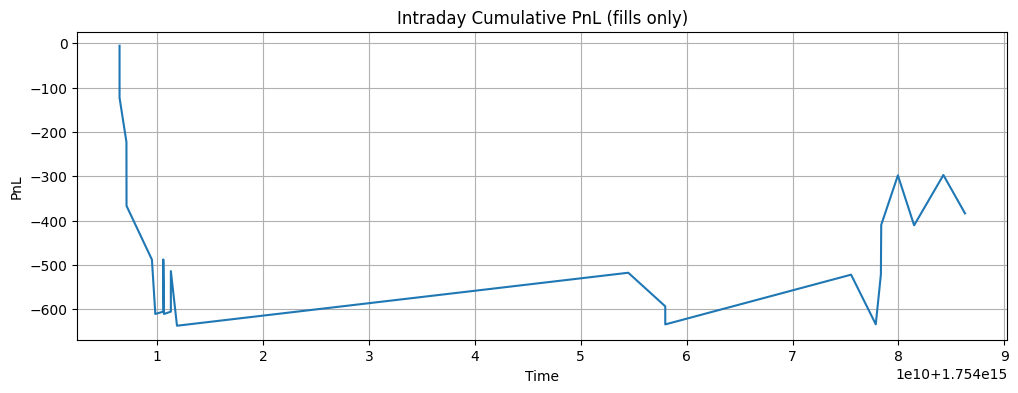

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,4))
plt.plot(fills_df["ts_us"], fills_df["cum_pnl"])
plt.title("Intraday Cumulative PnL (fills only)")
plt.xlabel("Time")
plt.ylabel("PnL")
plt.grid(True)
plt.show()

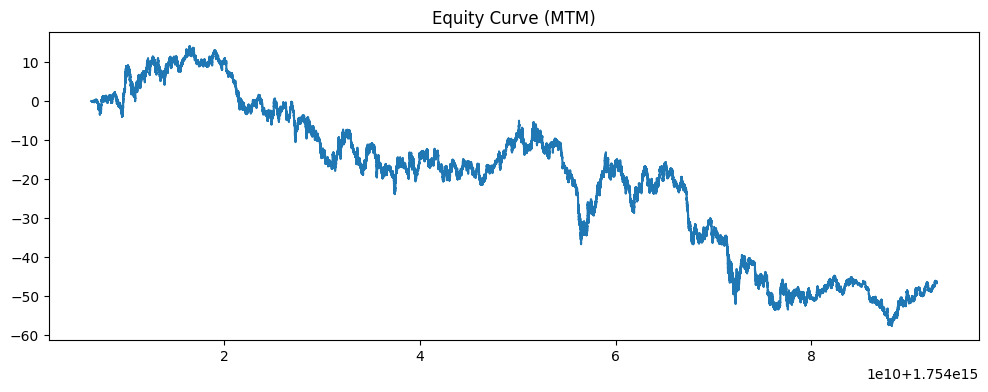

In [17]:
plt.figure(figsize=(12,4))
plt.plot(eq["ts_us"], eq["equity"])
plt.title("Equity Curve (MTM)")
plt.show()

In [18]:
log_df.groupby("action")["event_i"].count() / len(events_df)

action
CANCEL       0.000027
CANCEL_ALL   0.000423
FILL         0.000009
GATE         0.000012
PLACE        0.000027
REGIME       0.000883
Name: event_i, dtype: float64

# **Log Analysis**

**Step 1 — Build an “episode table” (each regime window)**

We want to group everything between enter_regime and exit_regime into episodes so we can see what happened per opportunity.

What to look for:

- Are episodes super short (like tens of ms)? → regime threshold chatter
- Are many episodes long but we don’t place? → toxicity filter too strict / tight spread

In [20]:
ld = log_df.copy().sort_values(["ts_us","event_i"]).reset_index(drop=True)

# mark regime flips
reg = ld[(ld.action=="REGIME") & (ld.reason.isin(["enter_regime","exit_regime"]))][
    ["ts_us","event_i","reason","spread_bps","med_bps","pos"]
].copy()

# pair enter->exit
enters = reg[reg.reason=="enter_regime"].reset_index(drop=True)
exits  = reg[reg.reason=="exit_regime"].reset_index(drop=True)

# if counts mismatch (end of day), align by index min len
m = min(len(enters), len(exits))
episodes = pd.DataFrame({
    "enter_ts_us": enters.loc[:m-1, "ts_us"].values,
    "enter_event_i": enters.loc[:m-1, "event_i"].values,
    "enter_spread_bps": enters.loc[:m-1, "spread_bps"].values,
    "enter_med_bps": enters.loc[:m-1, "med_bps"].values,
    "enter_pos": enters.loc[:m-1, "pos"].values,
    "exit_ts_us": exits.loc[:m-1, "ts_us"].values,
    "exit_event_i": exits.loc[:m-1, "event_i"].values,
})

episodes["dur_ms"] = (episodes["exit_ts_us"] - episodes["enter_ts_us"]) / 1000.0
episodes.describe()

,enter_ts_us,enter_event_i,enter_spread_bps,enter_med_bps,enter_pos,exit_ts_us,exit_event_i,dur_ms
count,1333.000000,1333.000000,1333.000000,1333.000000,1333.000000,1333.000000,1333.000000,1333.000000
mean,1754053151555318.250000,1561413.316579,2.802206,0.273796,13.448657,1754053151607701.250000,1561424.231808,52.383346
std,25613034432.535168,896995.319189,1.465179,0.069885,2.980231,25613034348.692474,896995.167265,4.254931
min,1754006462405000.000000,4187.000000,1.686117,0.240399,0.000000,1754006462456000.000000,4199.000000,51.000000
25%,1754032383142000.000000,806178.000000,2.014555,0.249934,12.640000,1754032383193000.000000,806186.000000,51.000000
50%,1754056847959000.000000,1615567.000000,2.390026,0.256486,15.640000,1754056848012000.000000,1615569.000000,51.000000
75%,1754075100115000.000000,2353186.000000,3.116236,0.267148,15.640000,1754075100229000.000000,2353209.000000,52.000000
max,1754092650117000.000000,3016840.000000,31.840347,0.953621,15.640000,1754092650171000.000000,3016841.000000,114.000000


<Axes: >

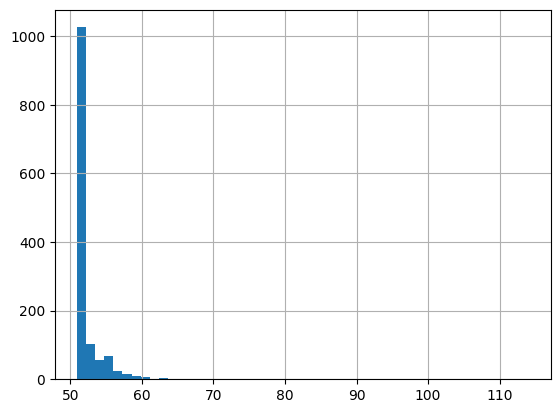

In [22]:
episodes["dur_ms"].hist(bins=50)

In [30]:
qt = quotes_df.sort_values("ts_us")
qt["dt_ms"] = qt["ts_us"].diff() / 1000
qt["dt_ms"].describe()

count   1333852.000000
mean         64.774671
std          36.936217
min          51.000000
25%          52.000000
50%          53.000000
75%          56.000000
max        1628.000000
Name: dt_ms, dtype: float64

In [31]:
b

np.float64(0.981245311327832)

**Step 2 — Per-episode action summary (why we didn’t trade)**

Interpretation rules:
- places=0 in many episodes → you’re in regime but blocked (tox_fail or tight spread)
- places>0 but fills=0 → either TTL too short, or fill engine too strict, or market didn’t trade-through
- Many CANCEL_ALL tox_fail inside episodes → toxicity filter dominates; you’re “too safe”

This tells us which knob matters first.

In [25]:
def summarize_episode(ep):
    sub = ld[(ld.ts_us>=ep.enter_ts_us) & (ld.ts_us<=ep.exit_ts_us)]
    out = {
        "places": int((sub.action=="PLACE").sum()),
        "cancels": int((sub.action=="CANCEL").sum()),
        "fills": int((sub.action=="FILL").sum()),
        "cancel_all": int((sub.action=="CANCEL_ALL").sum()),
        "gate": int((sub.action=="GATE").sum()),
    }
    # most common cancel_all reason
    if out["cancel_all"]>0:
        out["top_block"] = sub[sub.action=="CANCEL_ALL"]["reason"].value_counts().idxmax()
    else:
        out["top_block"] = None
    return pd.Series(out)

ep_stats = episodes.apply(summarize_episode, axis=1)
episodes2 = pd.concat([episodes, ep_stats], axis=1)

episodes2["fill_rate_ep"] = episodes2["fills"] / episodes2["places"].replace(0,np.nan)
#episodes2.sort_values(["fills","places"], ascending=False).head(20)
episodes2.sort_values(["fills","places"], ascending=False).head(5)

,enter_ts_us,enter_event_i,enter_spread_bps,enter_med_bps,enter_pos,exit_ts_us,exit_event_i,dur_ms,places,cancels,fills,cancel_all,gate,top_block,fill_rate_ep
0,1754006462405000,4187,1.956756,0.244565,0.000000,1754006462456000,4199,51.000000,2.000000,2.000000,3.000000,0.000000,0.000000,NaN,1.500000
110,1754010591828000,166954,2.196488,0.244078,15.000000,1754010591879000,166960,51.000000,1.000000,1.000000,3.000000,0.000000,1.000000,NaN,3.000000
13,1754007113582000,28966,1.966907,0.245842,3.000000,1754007113633000,28974,51.000000,2.000000,2.000000,2.000000,0.000000,0.000000,NaN,1.000000
703,1754057985233000,1675496,1.801547,0.257344,12.640000,1754057985286000,1675498,53.000000,2.000000,2.000000,2.000000,0.000000,0.000000,NaN,1.000000
138,1754011306308000,193675,2.192742,0.243668,15.000000,1754011306360000,193678,52.000000,1.000000,1.000000,2.000000,0.000000,1.000000,NaN,2.000000


In [32]:
episodes2[episodes2.dur_ms > 100][["dur_ms","places","fills","top_block"]].describe()

,dur_ms,places,fills
count,5.000000,5.000000,5.000000
mean,106.800000,0.000000,0.000000
std,4.764452,0.000000,0.000000
min,102.000000,0.000000,0.000000
25%,104.000000,0.000000,0.000000
50%,105.000000,0.000000,0.000000
75%,109.000000,0.000000,0.000000
max,114.000000,0.000000,0.000000


In [26]:
episodes2.describe()

,enter_ts_us,enter_event_i,enter_spread_bps,enter_med_bps,enter_pos,exit_ts_us,exit_event_i,dur_ms,places,cancels,fills,cancel_all,gate,fill_rate_ep
count,1333.000000,1333.000000,1333.000000,1333.000000,1333.000000,1333.000000,1333.000000,1333.000000,1333.000000,1333.000000,1333.000000,1333.000000,1333.000000,59.000000
mean,1754053151555318.250000,1561413.316579,2.802206,0.273796,13.448657,1754053151607701.250000,1561424.231808,52.383346,0.062266,0.062266,0.019505,0.959490,0.026257,0.288136
std,25613034432.535168,896995.319189,1.465179,0.069885,2.980231,25613034348.692474,896995.167265,4.254931,0.307357,0.307357,0.180699,0.215420,0.159957,0.558657
min,1754006462405000.000000,4187.000000,1.686117,0.240399,0.000000,1754006462456000.000000,4199.000000,51.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1754032383142000.000000,806178.000000,2.014555,0.249934,12.640000,1754032383193000.000000,806186.000000,51.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000
50%,1754056847959000.000000,1615567.000000,2.390026,0.256486,15.640000,1754056848012000.000000,1615569.000000,51.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000
75%,1754075100115000.000000,2353186.000000,3.116236,0.267148,15.640000,1754075100229000.000000,2353209.000000,52.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.500000
max,1754092650117000.000000,3016840.000000,31.840347,0.953621,15.640000,1754092650171000.000000,3016841.000000,114.000000,2.000000,2.000000,3.000000,2.000000,1.000000,3.000000


**Step 3 — Investigate fills properly (who, when, why)**

3.1 Which source contributes more (already)

You saw: quote_cross 15 vs trade_through 11.

Now check if quote_cross fills are happening right after placement (suspicious) or after some time (reasonable).

In [27]:
fills = ld[ld.action=="FILL"].copy()
fills["prev_place_ts_us"] = np.nan

# compute time since last PLACE of same order_id
places = ld[ld.action=="PLACE"][["ts_us","order_id"]].copy()
place_map = dict(zip(places.order_id, places.ts_us))

fills["place_ts_us"] = fills["order_id"].map(place_map)
fills["age_ms"] = (fills["ts_us"] - fills["place_ts_us"]) / 1000.0

fills.groupby("fill_source")["age_ms"].describe()

,count,mean,std,min,25%,50%,75%,max
fill_source,,,,,,,,
quote_cross,15.000000,54.933333,8.101734,51.000000,51.000000,51.000000,53.000000,78.000000
trade_through,11.000000,14.818182,7.846250,8.000000,11.000000,13.000000,14.000000,32.000000


In [28]:
fills["same_event_as_place"] = fills["event_i"].isin(
    ld[ld.action=="PLACE"]["event_i"].unique()
)
fills.groupby("fill_source")["same_event_as_place"].mean()

fill_source
quote_cross     0.000000
trade_through   0.000000
Name: same_event_as_place, dtype: float64

**Step 4 — Check regime “chatter” (this is likely your biggest issue)**

You have 2666 REGIME logs, but only 83 placements. That suggests regime flips constantly.

In [29]:
reg = ld[(ld.action=="REGIME") & (ld.reason.isin(["enter_regime","exit_regime"]))][["ts_us","reason"]]
reg["dt_ms"] = reg.ts_us.diff() / 1000.0
reg["flip"] = reg.reason

reg["dt_ms"].describe()

count      2665.000000
mean      32340.625141
std       78526.995171
min          51.000000
25%          51.000000
50%         114.000000
75%       28153.000000
max     1468935.000000
Name: dt_ms, dtype: float64